# Chapter 9 — Batch vs. Online Learning

**A correction worth making explicit first:** Chapters 1–7 always fed the
network's `forward()` and `backward()` functions the *entire* dataset at once
(all 4 rows of the OR/XOR truth table) and took exactly **one weight update per
epoch**. That's **full-batch gradient descent**, not online learning — this
notebook explains the difference, shows what online (and mini-batch) training
actually look like in code, and then justifies why batch was the right choice
for this series specifically.

## Part 1 — Three ways to turn data into a weight update

Every training loop repeats: *look at some data → compute a gradient →
step the weights.* The three regimes differ only in **how much data you look
at before each step**:

| Regime | Samples per update | Updates per epoch (n samples) |
|---|---|---|
| **Batch** (a.k.a. full-batch) | all `n` samples | 1 |
| **Online** (a.k.a. SGD, stochastic) | 1 sample | `n` |
| **Mini-batch** | a chunk of size `b` (`1 < b < n`) | `n / b` |

$$w \leftarrow w - \eta \cdot \frac{1}{|B|}\sum_{i \in B} \nabla_w L_i \qquad \text{— same formula every time, only } B \text{ (the batch) changes size}$$

Batch computes the *exact* gradient of the loss over the whole dataset. Online
computes a noisy one-sample *estimate* of that same gradient — cheap, but
jittery. Mini-batch is the compromise real systems actually use.

## Part 2 — One trainer, three regimes

Reuse the exact `forward` / `backward` from Chapters 3 and 5 — the only new
code is *how the data is sliced* before each weight update. Setting
`batch_size = n` reproduces every training loop from Chapters 1–7 exactly.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def relu_deriv(z):
    return (z > 0).astype(float)

def forward(X, W1, b1, W2, b2):
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    A2 = sigmoid(Z2)
    return Z1, A1, Z2, A2

def bce_loss(A2, y):
    y = y.reshape(A2.shape)
    eps = 1e-12
    p = np.clip(A2, eps, 1 - eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def backward(X, y, Z1, A1, Z2, A2, W2):
    n = X.shape[0]
    y = y.reshape(A2.shape)
    dZ2 = (A2 - y) / n
    dW2 = A1.T @ dZ2
    db2 = dZ2.sum(axis=0)
    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_deriv(Z1)
    dW1 = X.T @ dZ1
    db1 = dZ1.sum(axis=0)
    return dW1, db1, dW2, db2


def train(X, y, n_hidden, lr, epochs, batch_size, seed=0, shuffle=True, shuffle_seed=None):
    """batch_size == n  -> batch (Chapters 1-7's regime)
       batch_size == 1  -> online / SGD
       1 < batch_size < n -> mini-batch
       `seed` controls weight initialization; `shuffle_seed` (defaults to `seed`)
       controls the per-epoch sample order, kept separate so the two sources
       of randomness can be varied independently."""
    rng = np.random.default_rng(seed)
    rng_shuffle = np.random.default_rng(seed if shuffle_seed is None else shuffle_seed)
    n = X.shape[0]
    W1 = rng.normal(scale=1.0, size=(X.shape[1], n_hidden)); b1 = np.zeros(n_hidden)
    W2 = rng.normal(scale=1.0, size=(n_hidden, 1)); b2 = np.zeros(1)

    epoch_losses = []
    for epoch in range(epochs):
        order = rng_shuffle.permutation(n) if shuffle else np.arange(n)
        for start in range(0, n, batch_size):
            idx = order[start:start + batch_size]
            Xb, yb = X[idx], y[idx]
            Z1, A1, Z2, A2 = forward(Xb, W1, b1, W2, b2)
            dW1, db1, dW2, db2 = backward(Xb, yb, Z1, A1, Z2, A2, W2)
            W1 -= lr * dW1; b1 -= lr * db1
            W2 -= lr * dW2; b2 -= lr * db2

        # Score on the FULL dataset at the end of each epoch, so the three
        # regimes are compared on the same yardstick regardless of batch_size.
        _, _, _, A2_full = forward(X, W1, b1, W2, b2)
        epoch_losses.append(bce_loss(A2_full, y))

    return W1, b1, W2, b2, epoch_losses

## Part 3 — Watching the three regimes learn XOR

Same data, same seed, same learning rate, same number of epochs — the only
thing that changes below is `batch_size`.

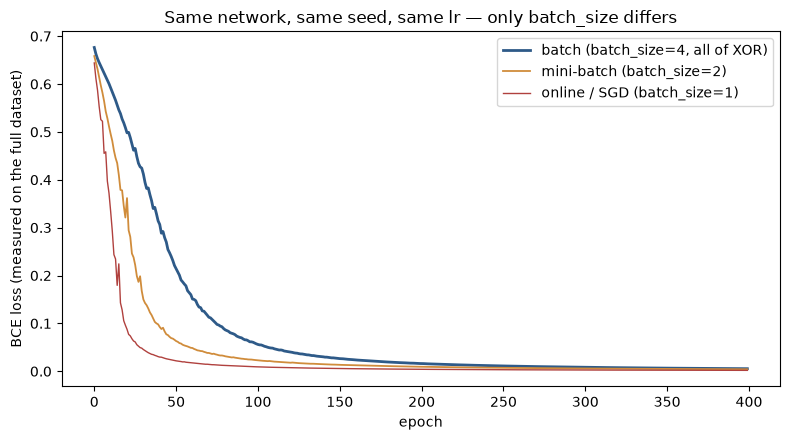

final loss  batch: 0.00539
final loss  mini-batch: 0.00419
final loss  online: 0.00193


In [2]:
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=float)
y_xor = np.array([0, 1, 1, 0], dtype=float)

_, _, _, _, losses_batch  = train(X_xor, y_xor, n_hidden=4, lr=0.5, epochs=400, batch_size=4, seed=1)
_, _, _, _, losses_mini   = train(X_xor, y_xor, n_hidden=4, lr=0.5, epochs=400, batch_size=2, seed=1)
_, _, _, _, losses_online = train(X_xor, y_xor, n_hidden=4, lr=0.5, epochs=400, batch_size=1, seed=1)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(losses_batch,  label='batch (batch_size=4, all of XOR)',   color='#2E5A88', linewidth=2)
ax.plot(losses_mini,   label='mini-batch (batch_size=2)',          color='#D08C3B', linewidth=1.3)
ax.plot(losses_online, label='online / SGD (batch_size=1)',        color='#B0413E', linewidth=1)
ax.set_xlabel('epoch'); ax.set_ylabel('BCE loss (measured on the full dataset)')
ax.set_title('Same network, same seed, same lr — only batch_size differs')
ax.legend()
plt.tight_layout()
plt.show()

print("final loss  batch:", round(losses_batch[-1], 5))
print("final loss  mini-batch:", round(losses_mini[-1], 5))
print("final loss  online:", round(losses_online[-1], 5))

Batch traces the smoothest curve — every step is the *exact* downhill
direction for the true loss. Online is visibly noisier: each step only sees
one XOR row, so its gradient is a rough estimate that can occasionally move
the wrong way before self-correcting on the next sample. Mini-batch sits
between the two, as the table in Part 1 predicted.

## Part 4 — The noise is real, and it's a random-seed thing for online

Batch gradient descent from a fixed seed is **fully deterministic** — rerun it
and you get bit-for-bit the same curve, because there's no shuffling and no
subsampling. Online training reshuffles the single-sample order every epoch,
so *which* sample you see first changes the trajectory. Run online training
three times with three different shuffle seeds to see the variance batch never has:

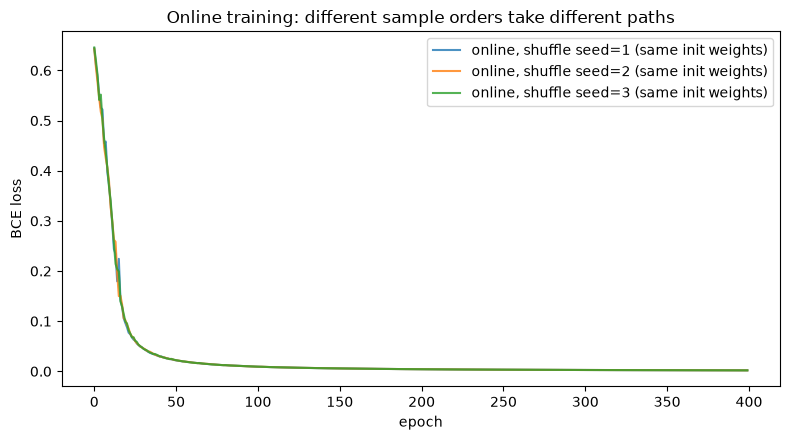

Batch gradient descent has no such variance to plot — same seed always
produces the identical curve, because it never subsamples the data.


In [3]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for shuffle_seed in [1, 2, 3]:
    _, _, _, _, losses = train(X_xor, y_xor, n_hidden=4, lr=0.5, epochs=400,
                                batch_size=1, seed=1, shuffle=True, shuffle_seed=shuffle_seed)
    ax.plot(losses, alpha=0.8, label=f'online, shuffle seed={shuffle_seed} (same init weights)')

ax.set_xlabel('epoch'); ax.set_ylabel('BCE loss')
ax.set_title('Online training: different sample orders take different paths')
ax.legend()
plt.tight_layout()
plt.show()

print("Batch gradient descent has no such variance to plot — same seed always")
print("produces the identical curve, because it never subsamples the data.")

## Part 5 — Why this series chose batch

With that comparison in hand, three concrete reasons batch was the right
default for Chapters 1–7:

1. **The dataset is 4 rows.** There is no memory or compute reason to ever
   look at less than all of it — "mini-batching" a 4-row dataset only adds
   noise for no benefit. Batch, mini-batch, and online all cost the same
   (trivial) amount of compute here; only their *noise* differs.
2. **Chapter 5's gradient checking needs a fixed target.** Numerically
   verifying `dL/dW` by nudging a weight and re-measuring the loss only makes
   sense if "the loss" is one well-defined number — the *full-dataset* loss.
   If training had used online or mini-batch updates, the loss being checked
   at any instant would depend on which sample(s) happened to be in the
   current batch, and the clean apples-to-apples comparison in Chapter 5 and
   Chapter 8 would have needed extra bookkeeping to even set up correctly.
3. **Reproducible, monotonic loss curves teach better.** Every loss curve in
   Chapters 1, 6, and 7 (and the seed-sensitivity scan in Chapter 7) relies on
   "same seed → same curve, every run." Batch gives that for free. It also
   means a failed run (Chapter 7's seed-7 story) is unambiguously due to
   initialization, not batch-order noise — online training would have
   confounded the two.

## Part 6 — When you'd choose online or mini-batch instead

None of the above is an argument that batch is *generally* better — it's an
argument that batch was right **for a 4-row teaching example.** In real
systems, the trade flips almost entirely:

- **Datasets don't fit in memory.** ImageNet-scale (millions of images) or
  web-scale text can't be forward-passed in one shot; mini-batches of a few
  hundred/thousand examples are the only option that fits on a GPU.
- **More updates per unit of data.** Batch takes one step per full pass over
  the data; mini-batch/online take many. On huge datasets, taking thousands of
  small, slightly-noisy steps usually reaches a good solution faster (in wall
  -clock time) than taking one perfectly-accurate step per epoch.
- **The noise is a feature, not just a bug.** SGD's per-step noise acts as a
  mild implicit regularizer and can help the optimizer hop out of sharp,
  narrow minima into flatter ones that tend to generalize better to unseen
  data — something a perfectly smooth batch trajectory doesn't get "for free."
- **Streaming / online-arriving data.** Recommender systems, ad ranking, or
  any setting where the "whole dataset" doesn't exist upfront (new data keeps
  arriving) has no choice but to update online, one arriving sample at a time.
- **Mini-batch is the real-world default** (commonly 32–256 examples) because
  it's the sweet spot: enough averaging to tame the noise batch avoids
  entirely, small enough to fit in memory and take many updates per epoch, and
  a good match for how GPUs parallelize matrix multiplication.

## Recap

| | Batch | Mini-batch | Online (SGD) |
|---|---|---|---|
| Samples per update | all `n` | `b` (e.g. 32–256) | 1 |
| Gradient | exact | noisy estimate | very noisy estimate |
| Updates per epoch | 1 | `n/b` | `n` |
| Reproducibility | deterministic | needs a fixed shuffle seed | needs a fixed shuffle seed |
| Best for | tiny datasets, exact verification, teaching | most real training | streaming data, huge `n`, memory-constrained |

Chapters 1–7 used batch deliberately, for a dataset small enough that it's the
simplest correct choice. Swap in `batch_size=32` (or smaller) the moment the
dataset stops being 4 rows of a truth table and starts being thousands of
real examples — the `forward`/`backward` math doesn't change at all; only how
much data feeds each update does.